# **Airbnb Price Prediction Using Machine Learning**

End-to-end regression project using Python, Pandas and Scikit-learn to predict Airbnb listing prices.

### **Project Overview**

This project develops a supervised machine learning regression pipeline to predict Airbnb listing prices from property, location, accommodation and availability characteristics.

The analysis follows an end-to-end data science workflow: exploratory data analysis (EDA), data cleaning, feature engineering, target transformation, model training, model comparison and model interpretation.

The dataset contains **48,895 Airbnb listings and 16 original variables**. Listing prices are highly right-skewed and contain extreme values, so a logarithmic transformation is applied to the target variable before regression modelling.

### **Objectives**

The main objectives of this project are to:

- Understand the structure and quality of the Airbnb dataset.
- Explore relationships between listing characteristics and price.
- Identify missing values, unusual observations and skewed variables.
- Prepare numerical and categorical features for machine learning.
- Apply a log transformation to the price target.
- Train and compare multiple regression algorithms.
- Evaluate models using MAE, RMSE and R².
- Examine feature importance to improve model interpretability.
- Convert predictions back to the original price scale for practical interpretation.

## **1. Import Libraries and Load the Dataset**

In [49]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

pd.set_option("display.max_columns", None)
df = pd.read_csv('Airbnb_Listings.csv')

The dataset is loaded into a Pandas DataFrame called `df`. Pandas is used throughout the project for data inspection, cleaning and transformation, while NumPy supports numerical operations. Matplotlib and Seaborn are used for visualisation, and Scikit-learn provides the machine learning models and evaluation tools.

Using a relative file path makes the notebook easier to reproduce outside Google Colab. If the dataset is not included in the public GitHub repository, the notebook can still be reviewed, but the CSV must be supplied locally to rerun the analysis.

## **2. Initial Data Exploration**

In [50]:
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,19/10/2018,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,21/05/2019,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,05/07/2019,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,19/11/2018,0.10,1,0


`head()` displays the first five observations, providing an initial view of the dataset and its variables.

In [51]:
df.tail()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
48890,36484665,Charming one bedroom - newly renovated rowhouse,8232441,Sabrina,Brooklyn,Bedford-Stuyvesant,40.67853,-73.94995,Private room,70,2,0,NaN,NaN,2,9
48891,36485057,Affordable room in Bushwick/East Williamsburg,6570630,Marisol,Brooklyn,Bushwick,40.70184,-73.93317,Private room,40,4,0,NaN,NaN,2,36
48892,36485431,Sunny Studio at Historical Neighborhood,23492952,Ilgar & Aysel,Manhattan,Harlem,40.81475,-73.94867,Entire home/apt,115,10,0,NaN,NaN,1,27
48893,36485609,43rd St. Time Square-cozy single bed,30985759,Taz,Manhattan,Hell's Kitchen,40.75751,-73.99112,Shared room,55,1,0,NaN,NaN,6,2
48894,36487245,Trendy duplex in the very heart of Hell's Kitchen,68119814,Christophe,Manhattan,Hell's Kitchen,40.76404,-73.98933,Private room,90,7,0,NaN,NaN,1,23


`tail()` displays the final five observations and provides a quick check of the end of the dataset.

In [52]:
df.shape

(48895, 16)

The dataset contains **48,895 rows and 16 columns**, representing 48,895 Airbnb listings and their associated characteristics.

In [53]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     

`info()` provides the number of non-null observations and data types for each variable. This is useful for identifying missing values and distinguishing between numerical and categorical variables before preprocessing.

In [54]:
df.describe()

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,4.889500e+04,4.889500e+04,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,38843.000000,48895.000000,48895.000000
mean,1.901714e+07,6.762001e+07,40.728949,-73.952170,152.720687,7.029962,23.274466,1.373221,7.143982,112.781327
std,1.098311e+07,7.861097e+07,0.054530,0.046157,240.154170,20.510550,44.550582,1.680442,32.952519,131.622289
min,2.539000e+03,2.438000e+03,40.499790,-74.244420,0.000000,1.000000,0.000000,0.010000,1.000000,0.000000
25%,9.471945e+06,7.822033e+06,40.690100,-73.983070,69.000000,1.000000,1.000000,0.190000,1.000000,0.000000
50%,1.967728e+07,3.079382e+07,40.723070,-73.955680,106.000000,3.000000,5.000000,0.720000,1.000000,45.000000
75%,2.915218e+07,1.074344e+08,40.763115,-73.936275,175.000000,5.000000,24.000000,2.020000,2.000000,227.000000
max,3.648724e+07,2.743213e+08,40.913060,-73.712990,10000.000000,1250.000000,629.000000,58.500000,327.000000,365.000000


`describe()` summarises the numerical variables using statistics such as the mean, standard deviation, quartiles, minimum and maximum values.

The price variable has a substantially larger maximum than the typical listing price, indicating the presence of extreme observations. The distribution therefore requires further investigation before modelling.

## **3. Exploratory Data Analysis**


**Price Disribution:**

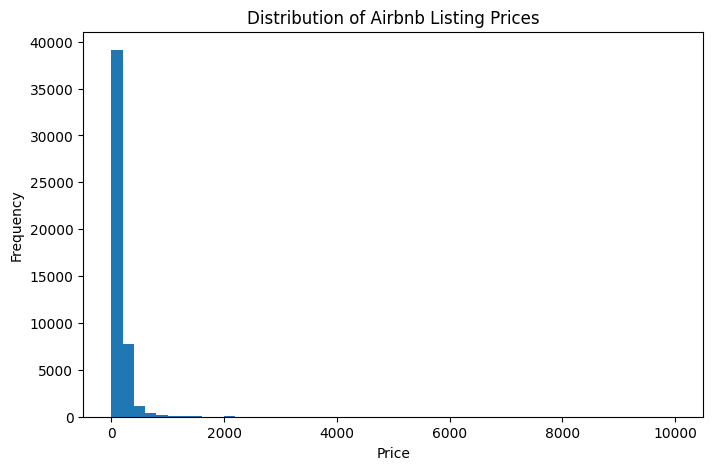

In [55]:
plt.figure(figsize= (8, 5))
plt.hist(df['price'], bins= 50)
plt.title('Distribution of Airbnb Listing Prices')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

The price distribution is strongly **positively skewed**. Most listings are concentrated at relatively lower prices, while a smaller number of listings have substantially higher prices.

This skewness can make regression models more sensitive to extreme observations. A logarithmic transformation of the target is therefore considered during preprocessing.

**Investigation of High Price Listings:**

In [56]:
df[df['price']>1000]

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
496,174966,Luxury 2Bed/2.5Bath Central Park View,836168,Henry,Manhattan,Upper West Side,40.77350,-73.98697,Entire home/apt,2000,30,30,05/05/2018,0.33,11,0
762,273190,6 Bedroom Landmark West Village Townhouse,605463,West Village,Manhattan,West Village,40.73301,-74.00268,Entire home/apt,1300,5,28,25/09/2018,0.31,4,297
946,363673,Beautiful 3 bedroom in Manhattan,256239,Tracey,Manhattan,Upper West Side,40.80142,-73.96931,Private room,3000,7,0,NaN,NaN,1,365
1105,468613,$ (Phone number hidden by Airbnb) weeks - room f,2325861,Cynthia,Manhattan,Lower East Side,40.72152,-73.99279,Private room,1300,1,0,NaN,NaN,1,0
1480,664047,Lux 2Bed/2.5Bath Central Park Views,836168,Henry,Manhattan,Upper West Side,40.77516,-73.98573,Entire home/apt,2000,30,59,28/01/2016,0.71,11,364
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48080,36074198,Luxury apartment 2 min to times square,203565865,Vinícius,Manhattan,SoHo,40.72060,-74.00023,Entire home/apt,1308,2,0,NaN,NaN,1,179
48304,36189195,Next to Times Square/Javits/MSG! Amazing 1BR!,270214015,Rogelio,Manhattan,Hell's Kitchen,40.75533,-73.99866,Entire home/apt,2999,30,0,NaN,NaN,1,222
48305,36189257,2BR Near Museum Mile! Upper East Side!,272166348,Mary Rotsen,Manhattan,Upper East Side,40.78132,-73.95262,Entire home/apt,1999,30,0,NaN,NaN,1,270
48523,36308562,"Tasteful & Trendy Brooklyn Brownstone, near Train",217732163,Sandy,Brooklyn,Bedford-Stuyvesant,40.68767,-73.95805,Entire home/apt,1369,1,0,NaN,NaN,1,349


Listings above $1,000 are inspected to determine whether extreme prices appear to be isolated data-entry errors or genuine observations. The presence of legitimate high-priced listings suggests that the extreme values should be treated as part of the underlying distribution rather than automatically removed.

**Distributions of Numerical Variables:**

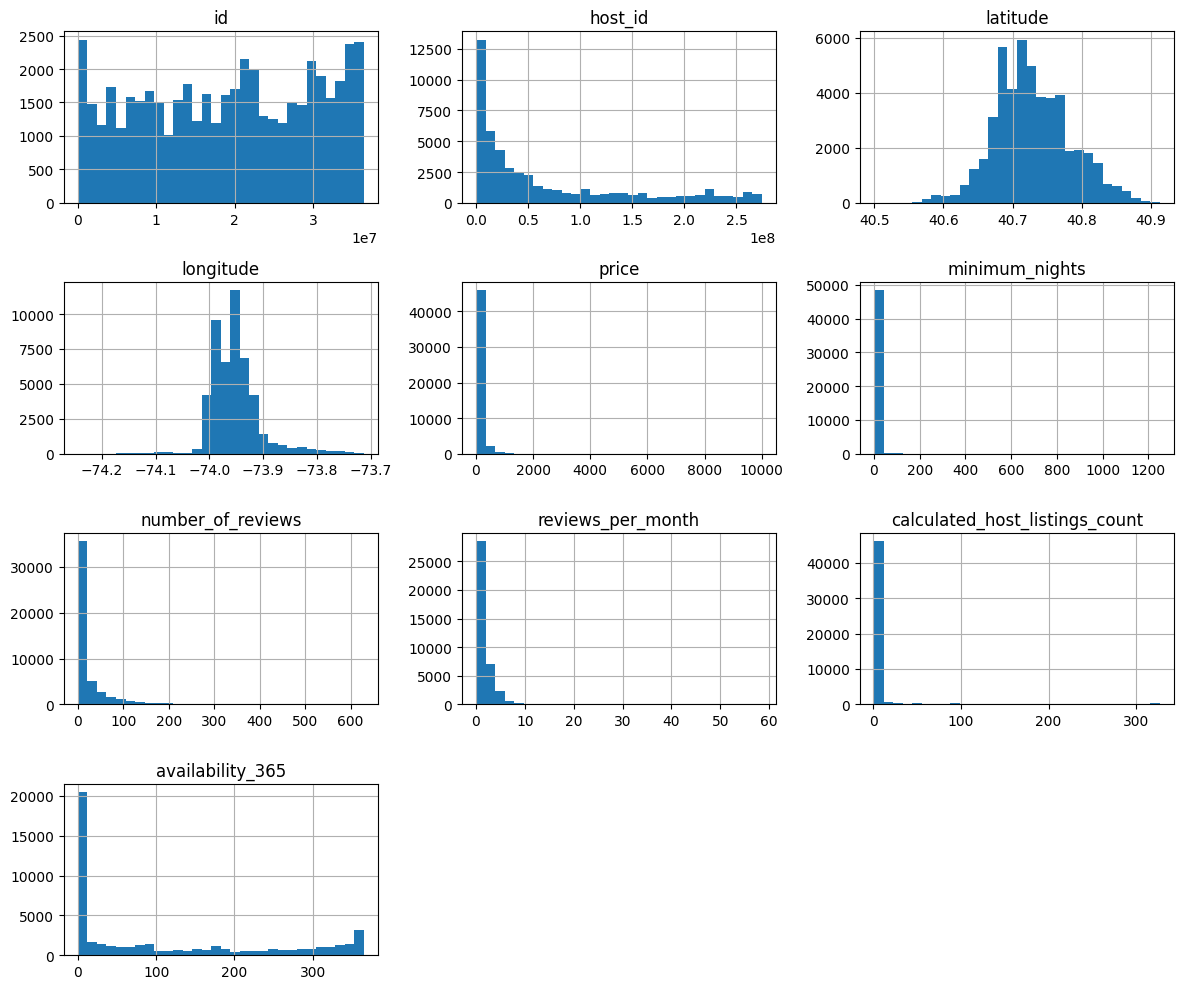

In [57]:
df.hist(figsize= (12, 10), bins= 30)
plt.tight_layout()
plt.show()

The numerical variables have different distributions and scales. `minimum_nights` is heavily concentrated at lower values, `availability_365` spans a wide range, and `number_of_reviews` is concentrated around lower review counts.

These differences reinforce the need for careful preprocessing before model training.

**Accommodation Type:**

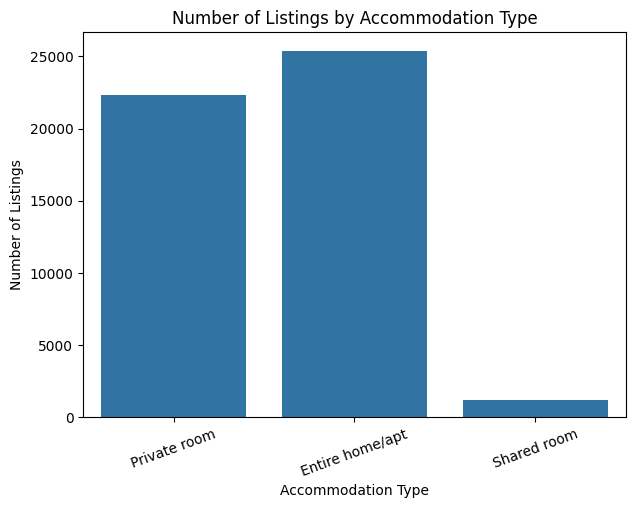

In [58]:
plt.figure(figsize=(7, 5))
sns.countplot(x="room_type", data=df)
plt.title("Number of Listings by Accommodation Type")
plt.xlabel("Accommodation Type")
plt.ylabel("Number of Listings")
plt.xticks(rotation=20)
plt.show()

Entire homes/apartments and private rooms make up the majority of listings, while shared rooms are less common. Accommodation type is therefore a potentially informative categorical feature for price prediction.

**Neighbourhood Group:**

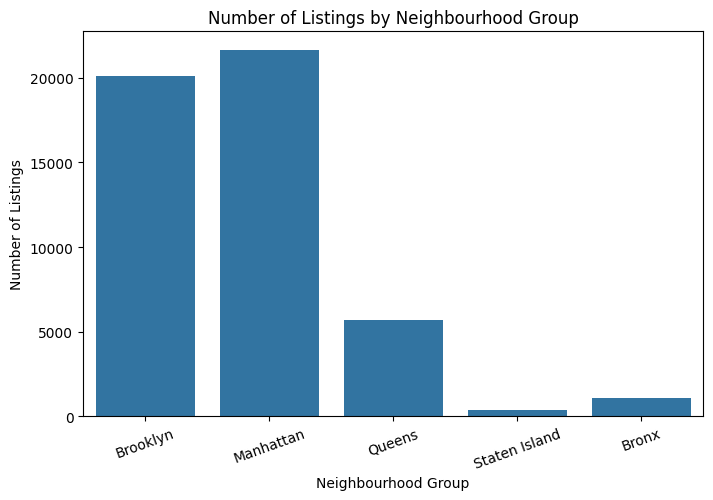

In [59]:
plt.figure(figsize=(8, 5))
sns.countplot(x="neighbourhood_group", data=df)
plt.title("Number of Listings by Neighbourhood Group")
plt.xlabel("Neighbourhood Group")
plt.ylabel("Number of Listings")
plt.xticks(rotation=20)
plt.show()

The distribution of listings differs considerably between neighbourhood groups. This suggests that geographical area may contain useful information for predicting price.

**Minimum Nights vs Price:**

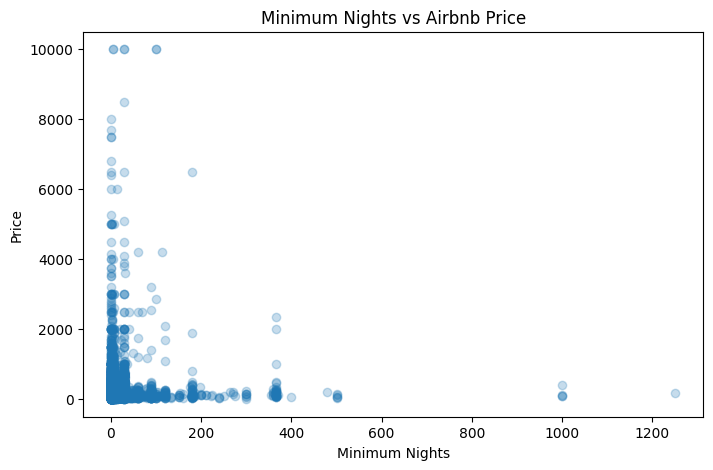

In [60]:
plt.figure(figsize=(8, 5))
plt.scatter(df["minimum_nights"], df["price"], alpha=0.25)
plt.title("Minimum Nights vs Airbnb Price")
plt.xlabel("Minimum Nights")
plt.ylabel("Price")
plt.show()

There is no clear linear relationship between minimum nights and price. However, the feature may still provide predictive information when combined with other variables.

**Number of Reviews vs Price:**

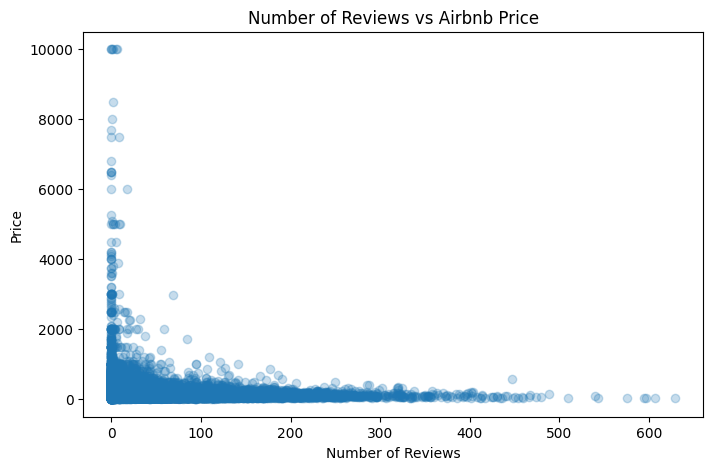

In [61]:
plt.figure(figsize=(8, 5))
plt.scatter(df["number_of_reviews"], df["price"], alpha=0.25)
plt.title("Number of Reviews vs Airbnb Price")
plt.xlabel("Number of Reviews")
plt.ylabel("Price")
plt.show()

Listings with large numbers of reviews tend to occur at lower or moderate price levels, while some expensive listings have relatively few reviews. This indicates that review count alone is unlikely to explain price, but it may contribute useful information alongside other features.

**Availability vs Price:**

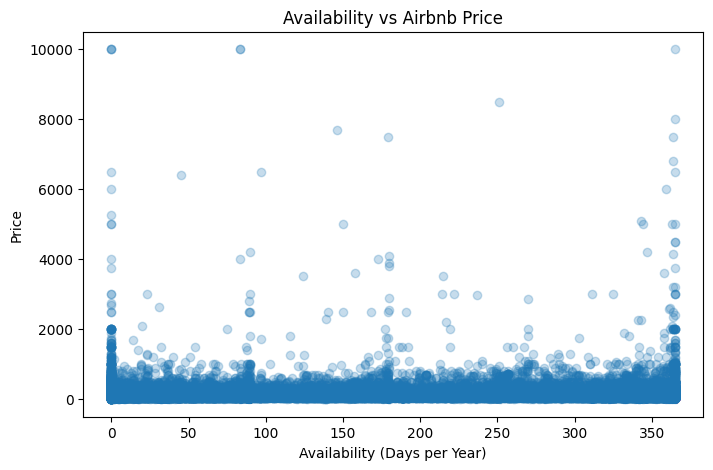

In [62]:
plt.figure(figsize=(8, 5))
plt.scatter(df["availability_365"], df["price"], alpha=0.25)
plt.title("Availability vs Airbnb Price")
plt.xlabel("Availability (Days per Year)")
plt.ylabel("Price")
plt.show()

Prices are distributed across a broad range of availability levels, with no obvious linear relationship. Availability may nevertheless contribute to predictions when combined with location, accommodation and other listing characteristics.

**Correlation Analysis:**

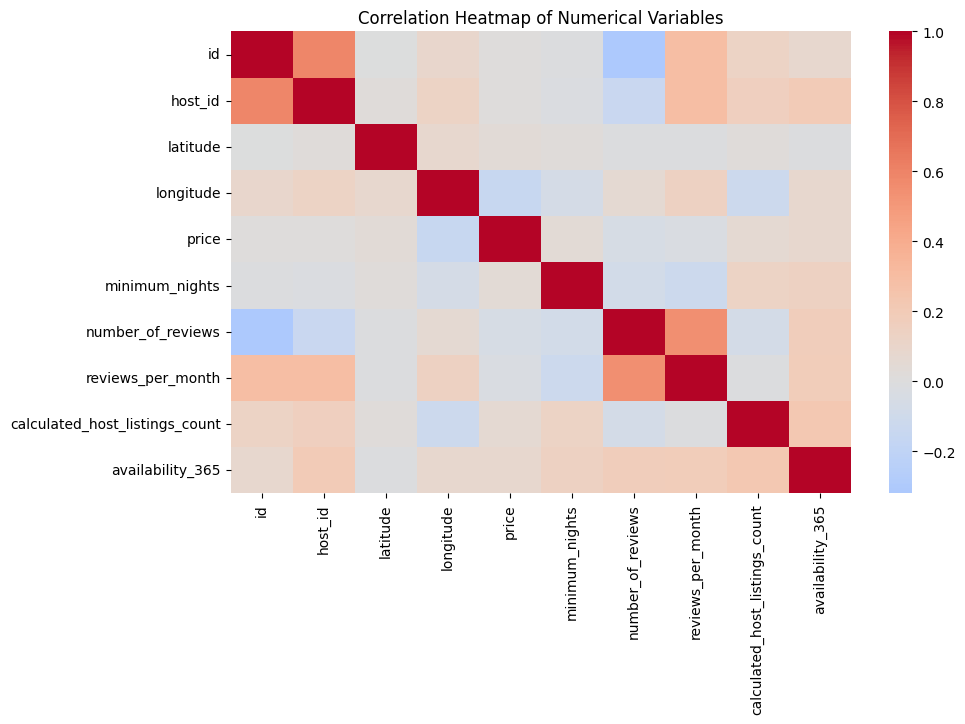

In [63]:
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(numeric_only=True), cmap="coolwarm", center=0)
plt.title("Correlation Heatmap of Numerical Variables")
plt.show()

The correlation heatmap shows that most numerical variables have relatively weak linear correlations with price. Some review-related variables show stronger relationships with each other.

The lack of a single dominant numerical predictor suggests that price is influenced by a combination of listing characteristics.

**Pairwise Relationships:**

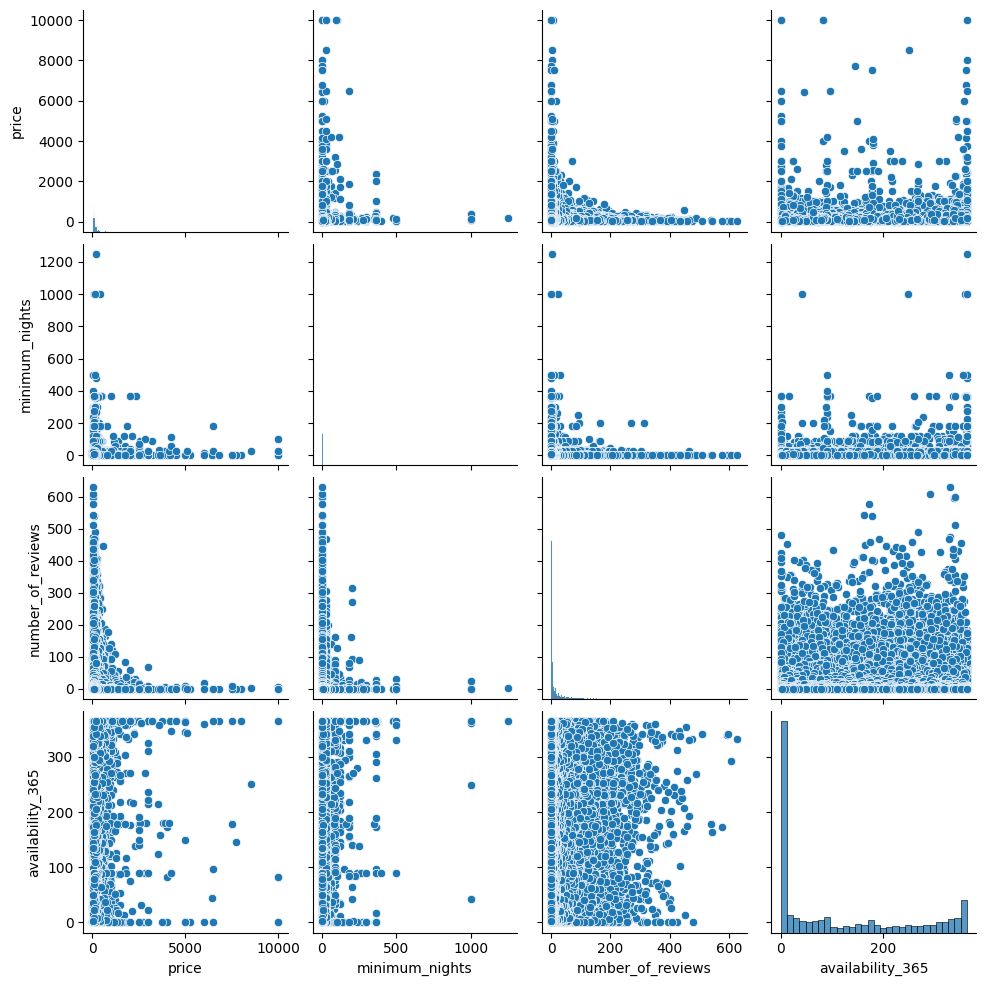

In [64]:
sns.pairplot(df[['price', 'minimum_nights', 'number_of_reviews', 'availability_365']])
plt.show()

The pairplot provides a broader view of relationships between selected numerical variables. Price remains heavily skewed and most pairwise relationships appear weak or non-linear, supporting the use of multiple features and non-linear models.

## **4. Data Preprocessing**

**Missing Value Analysis:**

In [65]:
df.isnull().sum()

,0
id,0
name,16
host_id,0
host_name,21
neighbourhood_group,0
neighbourhood,0
latitude,0
longitude,0
room_type,0
price,0


Missing values are concentrated in `last_review` and `reviews_per_month`. These variables are removed during preprocessing because a substantial proportion of their observations are missing.

**Feature Selection and Cleaning:**

In [66]:
df = df.drop(
    columns=[
        "name",
        "id",
        "host_id",
        "host_name",
        "last_review",
        "reviews_per_month",
        "neighbourhood"
    ]
)

Identifier fields such as `id`, `host_id`, `name` and `host_name` are excluded because they do not represent useful generalisable property characteristics.

`last_review` and `reviews_per_month` are removed because of their missing-data levels. `neighbourhood` is also excluded from the modelling dataset to reduce the number of high-cardinality location categories, while the broader `neighbourhood_group` variable is retained.

**Renaming Accommodation Variable**

In [67]:
df = df.rename(columns={"room_type": "accommodation_type"})
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 9 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   neighbourhood_group             48895 non-null  object 
 1   latitude                        48895 non-null  float64
 2   longitude                       48895 non-null  float64
 3   accommodation_type              48895 non-null  object 
 4   price                           48895 non-null  int64  
 5   minimum_nights                  48895 non-null  int64  
 6   number_of_reviews               48895 non-null  int64  
 7   calculated_host_listings_count  48895 non-null  int64  
 8   availability_365                48895 non-null  int64  
dtypes: float64(2), int64(5), object(2)
memory usage: 3.4+ MB


The `room_type` variable is renamed to `accommodation_type` to make its role clearer in the modelling workflow.

**Checking these changes to confirm that they've been successful:**

In [68]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 9 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   neighbourhood_group             48895 non-null  object 
 1   latitude                        48895 non-null  float64
 2   longitude                       48895 non-null  float64
 3   accommodation_type              48895 non-null  object 
 4   price                           48895 non-null  int64  
 5   minimum_nights                  48895 non-null  int64  
 6   number_of_reviews               48895 non-null  int64  
 7   calculated_host_listings_count  48895 non-null  int64  
 8   availability_365                48895 non-null  int64  
dtypes: float64(2), int64(5), object(2)
memory usage: 3.4+ MB


The changes have been sucessfully completed, with no errors.

**Logirithmic Transformation of Price**

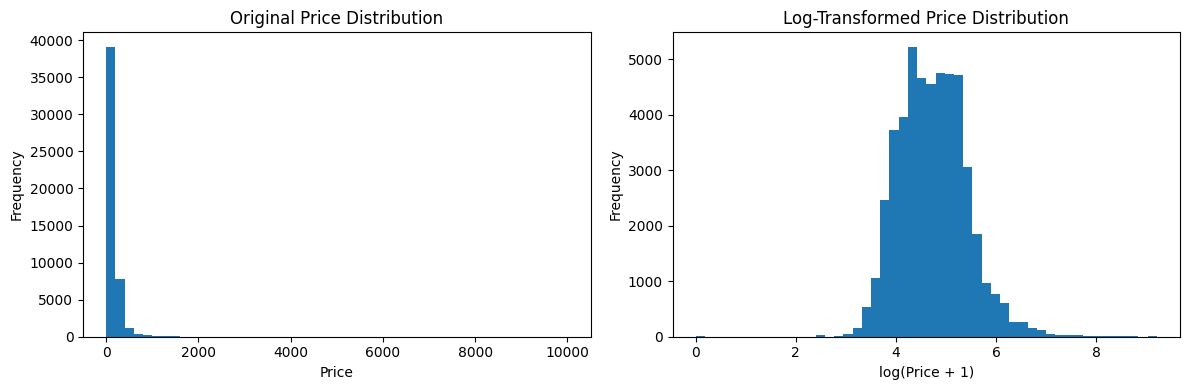

In [69]:
df["log_price"] = np.log1p(df["price"])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df["price"], bins=50)
axes[0].set_title("Original Price Distribution")
axes[0].set_xlabel("Price")
axes[0].set_ylabel("Frequency")

axes[1].hist(df["log_price"], bins=50)
axes[1].set_title("Log-Transformed Price Distribution")
axes[1].set_xlabel("log(Price + 1)")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

The target variable is transformed using `log1p(price)`. This reduces the influence of extreme price values and produces a less skewed target distribution, which can make regression modelling more stable.

The original `price` column is retained so predictions can later be converted back to the original price scale.

**One Hot Encoding**

In [70]:
df = pd.get_dummies(
    df,
    columns=["neighbourhood_group", "accommodation_type"],
    drop_first=True
)

df.head()

,latitude,longitude,price,minimum_nights,number_of_reviews,calculated_host_listings_count,availability_365,log_price,neighbourhood_group_Brooklyn,neighbourhood_group_Manhattan,neighbourhood_group_Queens,neighbourhood_group_Staten Island,accommodation_type_Private room,accommodation_type_Shared room
0,40.64749,-73.97237,149,1,9,6,365,5.010635,True,False,False,False,True,False
1,40.75362,-73.98377,225,1,45,2,355,5.420535,False,True,False,False,False,False
2,40.80902,-73.94190,150,3,0,1,365,5.017280,False,True,False,False,True,False
3,40.68514,-73.95976,89,1,270,1,194,4.499810,True,False,False,False,False,False
4,40.79851,-73.94399,80,10,9,1,0,4.394449,False,True,False,False,False,False


Categorical variables are converted into numerical indicator variables using one-hot encoding. `drop_first=True` removes one category from each encoded variable to avoid redundant dummy variables in the linear regression model.

## **5. Model Preperation**

**Define Features and Target:**

In [73]:
X = df.drop(columns=["price", "log_price"])
y = df["log_price"]

`X` contains the predictor variables and `y` contains the log-transformed price that the models will learn to predict. The original `price` column is excluded from the predictors to prevent the target from leaking directly into the model.

**Train-Test Split:**

In [74]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 39116
Testing samples: 9779


The data is divided into **80% training data and 20% testing data**. The training set is used to fit the models, while the unseen test set is reserved for evaluating how well the models generalise to new observations.

A fixed `random_state` of 42 makes the split reproducible.

**Feature Scalling:**

In [75]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

`StandardScaler` standardises the feature values so that variables are placed on comparable scales.

Importantly, the scaler is fitted only on the training data. The same transformation is then applied to the test data. This prevents information from the test set from influencing preprocessing and helps avoid data leakage.

## **6. Baseline Model: Linear Regression**

In [76]:
linear_regression = LinearRegression()
linear_regression.fit(X_train_scaled, y_train)

linear_predictions = linear_regression.predict(X_test_scaled)

Linear Regression is used as a baseline because it provides a simple benchmark for the more flexible ensemble models. It assumes a linear relationship between the predictors and the log-transformed price.

## **7. Model Prediction**

In [77]:
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(
        n_estimators=100,
        random_state=42
    ),
    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=100,
        random_state=42
    )
}

results = []

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    predictions = model.predict(X_test_scaled)

    mae = mean_absolute_error(y_test, predictions)
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    r2 = r2_score(y_test, predictions)

    results.append([name, mae, rmse, r2])

results_df = pd.DataFrame(
    results,
    columns=["Model", "MAE", "RMSE", "R2 Score"]
)

results_df.sort_values("RMSE")

,Model,MAE,RMSE,R2 Score
1,Random Forest,0.308448,0.433183,0.603355
2,Gradient Boosting,0.317293,0.440973,0.588962
0,Linear Regression,0.355294,0.486467,0.499776


Three regression algorithms are compared:

- **Linear Regression** provides a simple linear baseline.
- **Random Forest** combines multiple decision trees and can capture non-linear relationships and feature interactions.
- **Gradient Boosting** builds trees sequentially, with each new tree attempting to improve the previous model's errors.

The models are evaluated using the same test set. Because the target was log-transformed, the MAE and RMSE shown here are measured in **log-price units**.

## **8. Model Evaluation**

,Model,MAE,RMSE,R2 Score
1,Random Forest,0.308448,0.433183,0.603355
2,Gradient Boosting,0.317293,0.440973,0.588962
0,Linear Regression,0.355294,0.486467,0.499776


<Figure size 800x500 with 0 Axes>

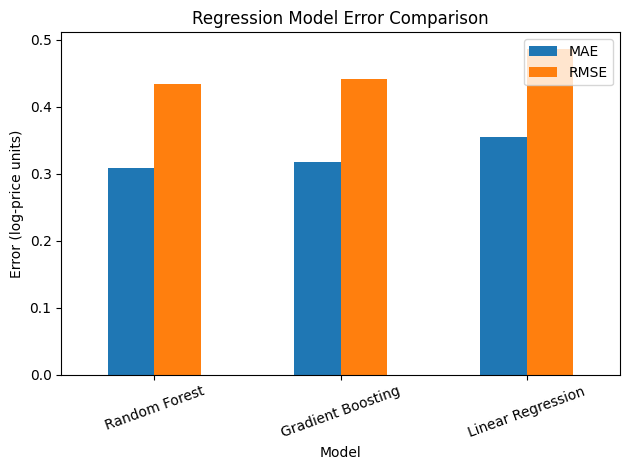

In [78]:
results_df = results_df.sort_values("RMSE")

display(results_df)

plt.figure(figsize=(8, 5))
results_df.set_index("Model")[["MAE", "RMSE"]].plot(kind="bar")
plt.title("Regression Model Error Comparison")
plt.ylabel("Error (log-price units)")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

Based on the recorded test-set results, Random Forest achieved the strongest overall performance:

- **Random Forest:** RMSE ≈ 0.433 and R² ≈ 0.603
- **Gradient Boosting:** RMSE ≈ 0.441 and R² ≈ 0.589
- **Linear Regression:** RMSE ≈ 0.486 and R² ≈ 0.500

The ensemble tree-based methods outperform the linear baseline, suggesting that the relationship between listing characteristics and price contains non-linear patterns.

Random Forest is selected as the final model because it achieved the lowest RMSE and highest R² among the evaluated models.

## **9. Final Model Predictions**

In [79]:
rf = models["Random Forest"]

pred_log = rf.predict(X_test_scaled)

pred_price = np.expm1(pred_log)
actual_price = np.expm1(y_test)

comparison = pd.DataFrame({
    "Actual Price": actual_price.iloc[:10].values,
    "Predicted Price": pred_price[:10]
})

comparison

,Actual Price,Predicted Price
0,89.0,121.728434
1,30.0,46.494728
2,120.0,95.961655
3,470.0,276.215824
4,199.0,176.602768
5,170.0,129.386429
6,90.0,70.151120
7,60.0,102.471769
8,150.0,225.406180
9,74.0,136.693335


The model predicts the logarithmically transformed price. `expm1()` reverses the earlier `log1p()` transformation so that predictions can be interpreted on the original price scale.

The table provides a direct comparison between actual and predicted listing prices for a sample of test observations.

**Actual vs Predicted Prices:**

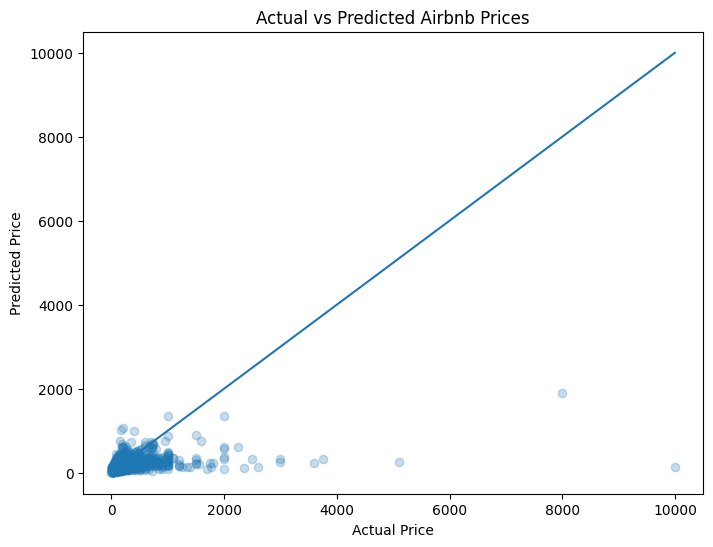

In [80]:
plt.figure(figsize=(8, 6))
plt.scatter(actual_price, pred_price, alpha=0.25)

min_price = min(actual_price.min(), pred_price.min())
max_price = max(actual_price.max(), pred_price.max())

plt.plot([min_price, max_price], [min_price, max_price])
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Airbnb Prices")
plt.show()

The actual-versus-predicted plot provides a visual assessment of prediction accuracy. Points closer to the diagonal line represent predictions that are closer to the observed prices.

## **10. Model Interpretability:**

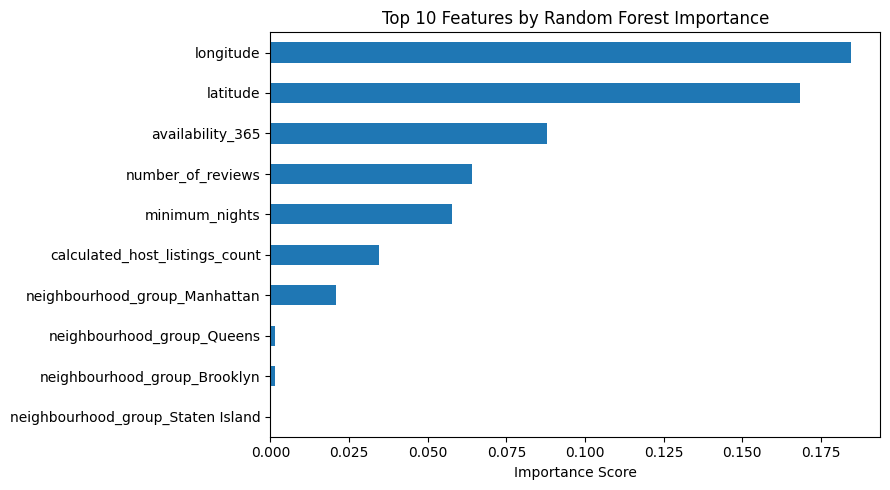

In [81]:
eature_importance = pd.Series(
    rf.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

plt.figure(figsize=(9, 5))
feature_importance.head(10).sort_values().plot(kind="barh")
plt.title("Top 10 Features by Random Forest Importance")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()

Random Forest feature importance is used to identify which predictors contribute most strongly to the model's decisions.

This provides an additional layer of interpretability and helps connect the model's predictions to characteristics of Airbnb listings. Feature importance indicates predictive contribution within this model; it should not be interpreted as proof that a feature causes changes in price.

## **11. Conclusion**

This project developed an end-to-end machine learning workflow for Airbnb price prediction.

The analysis began with exploratory data analysis to understand the dataset, identify missing values and investigate relationships between listing characteristics and price. The data was then cleaned, categorical variables were encoded, and the heavily skewed price target was log-transformed.

Three regression models were evaluated: Linear Regression, Random Forest and Gradient Boosting. The ensemble-based models outperformed the linear baseline, with Random Forest achieving the strongest recorded test-set performance.

Feature importance analysis was then used to improve model interpretability, while predictions were transformed back to the original price scale to make the results easier to understand.

Overall, the project demonstrates practical skills in data preprocessing, exploratory analysis, supervised machine learning, model evaluation and model interpretation using Python and Scikit-learn.

## **12. Future Improvements**

Possible extensions to this project include:

- Hyperparameter tuning using `GridSearchCV` or `RandomizedSearchCV`.
- Cross-validation to obtain more robust estimates of model performance.
- Testing additional algorithms such as XGBoost.
- Engineering richer geographical features from latitude and longitude.
- Performing more systematic outlier analysis.
- Comparing model performance before and after target transformation.
- Conducting residual analysis to identify systematic prediction errors.
- Developing an interactive application for generating Airbnb price predictions.